# 1. Instalar dependências

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

# 2. Carregar Dados

In [2]:
df = pd.read_csv('jogos.csv', sep=';')
df.head()
df.describe()

,achievements,dlc,horas_jogo,nota_metacritic,preco
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,50.314000,3.966000,25.423300,58.61000,36.722860
std,29.140257,2.588734,14.465305,23.37859,9.704374
min,0.000000,0.000000,0.000000,20.00000,10.590000
25%,25.000000,2.000000,12.450000,40.00000,29.805000
50%,51.000000,4.000000,24.800000,58.00000,36.300000
75%,76.000000,6.000000,38.200000,80.00000,43.785000
max,100.000000,8.000000,50.000000,99.00000,64.200000


# 3. Relação DLCs x Preço

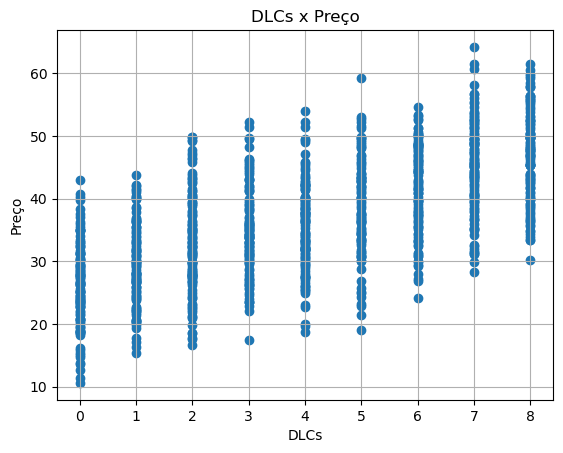

In [3]:
plt.figure()
plt.scatter(df['dlc'], df['preco'])
plt.xlabel('DLCs')
plt.ylabel('Preço')
plt.title('DLCs x Preço')
plt.grid(True)
plt.show()

# 4. Relação Horas de jogo x Preço

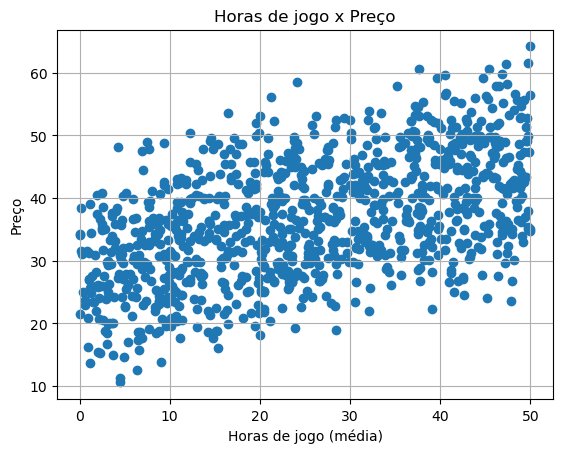

In [4]:
plt.figure()
plt.scatter(df['horas_jogo'], df['preco'])
plt.xlabel('Horas de jogo (média)')
plt.ylabel('Preço')
plt.title('Horas de jogo x Preço')
plt.grid(True)
plt.show()

# 5. Relação preço médio por média de notas positivas

/tmp/ipykernel_1506/3628682149.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_preco = df.groupby(faixa_nota)['preco'].mean().reindex(labels).fillna(0)


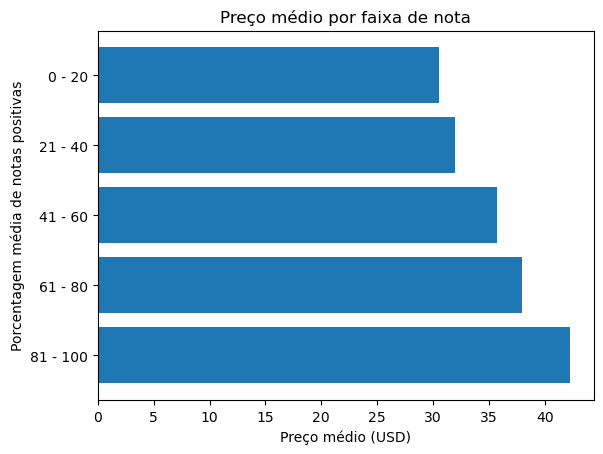

In [5]:
# Em vez do scatter "nota_metacritic x preço" (que fica muito disperso),
# agrupamos os jogos por faixa de nota e mostramos o preço médio de cada
# faixa, no estilo do gráfico de barras horizontais.
plt.figure()
bins = [0, 20, 40, 60, 80, 100]
labels = ['0 - 20', '21 - 40', '41 - 60', '61 - 80', '81 - 100']
faixa_nota = pd.cut(df['nota_metacritic'], bins=bins, labels=labels, include_lowest=True)
media_preco = df.groupby(faixa_nota)['preco'].mean().reindex(labels).fillna(0)
plt.barh(media_preco.index, media_preco.values)
plt.xlabel('Preço médio (USD)')
plt.ylabel('Porcentagem média de notas positivas')
plt.title('Preço médio por faixa de nota')
plt.gca().invert_yaxis()
plt.show()

# 6. Organização de dados e treinamento

In [6]:
# Separa variáveis
X = df[['dlc', 'horas_jogo', 'nota_metacritic']]
y = df['preco']

# Separa dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Total de jogos:', len(df))
print('Treino:', X_train.shape[0])
print('Teste:', X_test.shape[0])

# Treina o modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# help(modelo)
print('Coeficientes (b1, b2, b3):', modelo.coef_)
print('Intercepto (a):', modelo.intercept_)

# y = a + (b1 * x1) + (b2 * x2) + (b3 * x3)
# preço = a + (b1*dlc) + (b2*horas_jogo) + (b3*nota_metacritic)
a = modelo.intercept_
b1, b2, b3 = modelo.coef_
print(f'\npreço = {a:.2f} + ({b1:.2f}*dlc) + ({b2:.2f}*horas_jogo) + '
      f'({b3:.2f}*nota_metacritic)')

# Qual a qualidade do modelo nos dados de teste (0 a 1, quanto mais perto de 1, melhor)?
print('\nR² no conjunto de teste:', modelo.score(X_test, y_test))

Total de jogos: 1000
Treino: 800
Teste: 200
Coeficientes (b1, b2, b3): [2.51164565 0.35351954 0.15331146]
Intercepto (a): 8.742522589956003

preço = 8.74 + (2.51*dlc) + (0.35*horas_jogo) + (0.15*nota_metacritic)

R² no conjunto de teste: 0.8291635918829547


# 7. Teste do modelo

In [10]:
# Qual o preço para um dado jogo?
# dlc = 2
# horas_jogo = 26
# nota_metacritic = 59

dlc = None
horas_jogo = None
nota_metacritic = None

while True:
    dlc = int(input("Quantas DLCs tem o jogo: "))
    horas_jogo = float(input("Quantas horas de gameplay tem: "))
    nota_metacritic = float(input("Qual é a porcentagem de notas positivas na steam: "))
    
    if dlc or horas_jogo or nota_metacritic:
        break
    print("Alguma variavel está vazia")

entrada = pd.DataFrame([[dlc, horas_jogo, nota_metacritic]],
                        columns=['dlc', 'horas_jogo', 'nota_metacritic'])
preco = modelo.predict(entrada)
print('\nPreço sugerido para esse jogo: USD', preco[0].round(2))

Quantas DLCs tem o jogo:  2
Quantas horas de gameplay tem:  26
Qual é a porcentagem de notas positivas na steam:  59



Preço sugerido para esse jogo: USD 32.0
